# 🏥 Cataract Detection System
## Two-Stage AI Pipeline for Automated Cataract Detection & Severity Grading

**Final Year Research Project**

---

### Pipeline Overview
- **Stage 1:** Eye Image Detector (MobileNetV2) — verifies input is an eye image
- **Stage 2:** Cataract Classifier (ResNet50) — grades severity (Immature / Mature / Normal)

### Dataset Structure
```
Processed_Cataract_Data/
    train/ (Immature, Mature, Normal)
    valid/ (Immature, Mature, Normal)
    test/  (Immature, Mature, Normal)
```

> **Note:** Run cells in order. Ensure GPU is enabled (Runtime > Change runtime type > GPU).


# Environment Setup & GPU Configuration

Install dependencies, verify GPU availability, set random seeds for reproducibility, and import all required libraries.

---


# 🏥 Cataract Detection System
## Two-Stage AI Pipeline for Automated Cataract Detection & Severity Grading

**Final Year Research Project**

This notebook implements a complete two-stage deep learning pipeline:
- **Stage 1:** Eye Image Detector (MobileNetV2) — verifies input is an eye image
- **Stage 2:** Cataract Classifier (ResNet50) — grades cataract severity (Immature / Mature / Normal)

---

## Cell 1: Install Dependencies & GPU Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Install required packages
!pip install tensorflow -q
!pip install scikit-learn seaborn -q
!pip install opencv-python-headless -q

# Upgrade protobuf to resolve version incompatibility issues
!pip install protobuf==6.31.1 -q

!pip install tensorflow-datasets -q

# Suppress specific Protobuf warnings (if any persist after upgrade and restart)
# import os
# os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python' # or 'cpp'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.


In [2]:
import tensorflow as tf
import os, random, warnings
import numpy as np

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("=" * 60)
print("  CATARACT DETECTION SYSTEM")
print("  Two-Stage AI Pipeline for Automated Cataract")
print("  Detection and Severity Grading")
print("=" * 60)

# --------------------------------------------------
# GPU Verification (Google Colab GPU required)
# --------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
print(f"\nTensorFlow Version: {tf.__version__}")
print(f"GPU Available: {bool(gpus)}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU Name: {gpus[0].name}")
    print("✓ Memory growth enabled.")
else:
    print("⚠ WARNING: No GPU detected!")
    print("  Go to: Runtime > Change runtime type > Hardware accelerator > GPU")

# --------------------------------------------------
# Reproducibility — set random seeds
# --------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"\n✓ Random seed set to: {SEED}")

  CATARACT DETECTION SYSTEM
  Two-Stage AI Pipeline for Automated Cataract
  Detection and Severity Grading

TensorFlow Version: 2.20.0
GPU Available: True
GPU Name: /physical_device:GPU:0
✓ Memory growth enabled.

✓ Random seed set to: 42


## Cell 2: Import All Required Libraries

In [3]:
# ============================================================
# Import All Required Libraries
# ============================================================

# --- Deep Learning (TensorFlow / Keras) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0, DenseNet121
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical

# --- Computer Vision (OpenCV / PIL) ---
import cv2
from PIL import Image

# --- Data Handling ---
import numpy as np
import pandas as pd
import os, random, shutil, json, itertools

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("✓ All libraries imported successfully.")
print("  - TensorFlow / Keras (Deep Learning)")
print("  - OpenCV (Image Processing)")
print("  - scikit-learn (Evaluation Metrics)")
print("  - Matplotlib / Seaborn (Visualization)")

✓ All libraries imported successfully.
  - TensorFlow / Keras (Deep Learning)
  - OpenCV (Image Processing)
  - scikit-learn (Evaluation Metrics)
  - Matplotlib / Seaborn (Visualization)


# Mount Google Drive & Configuration

Mount Google Drive, verify the dataset directory structure, and define all hyperparameters and paths.

---


## Cell 3: Mount Google Drive & Verify Dataset

In [4]:
# ============================================================
# Mount Google Drive & Set Dataset Paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Define dataset path (stored in Google Drive)
DATASET_PATH = '/content/drive/MyDrive/Processed_Cataract_Data'

# --------------------------------------------------
# Verify dataset directory structure
# --------------------------------------------------
print("Dataset path:", DATASET_PATH)
print("\nDirectory structure:")
print("-" * 50)

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    print(f'{indent}{folder_name}/')
    # Show image count at class level (level 2 = split/class)
    if level == 2:
        print(f'{indent}  └── ({len(files)} images)')

print("-" * 50)

# Verify all required directories exist
required_splits = ['train', 'valid', 'test']
required_classes = ['Immature', 'Mature', 'Normal']

all_valid = True
for split in required_splits:
    for cls in required_classes:
        path = os.path.join(DATASET_PATH, split, cls)
        if not os.path.exists(path):
            print(f"⚠ MISSING: {path}")
            all_valid = False

if all_valid:
    print("✓ All dataset directories verified successfully!")

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Processed_Cataract_Data

Directory structure:
--------------------------------------------------
Processed_Cataract_Data/
  train/
    Normal/
      └── (1304 images)
    Immature/
      └── (1125 images)
    Mature/
      └── (1283 images)
  test/
    Normal/
      └── (448 images)
    Immature/
      └── (368 images)
    Mature/
      └── (421 images)
  valid/
    Normal/
      └── (414 images)
    Immature/
      └── (387 images)
    Mature/
      └── (436 images)
--------------------------------------------------
✓ All dataset directories verified successfully!


## Cell 4: Configuration & Hyperparameters

In [5]:
# ============================================================
# Configuration & Hyperparameters
# ============================================================

# --- Image dimensions ---
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# --- Training hyperparameters ---
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20        # Eye detector epochs per phase
EPOCHS_STAGE2 = 30        # Cataract classifier epochs per phase
LEARNING_RATE = 1e-4       # Initial learning rate (feature extraction)
FINE_TUNE_LR = 1e-5      # Lower learning rate for fine-tuning

# --- Eye detector threshold ---
EYE_CONFIDENCE_THRESHOLD = 0.5  # If eye_prob < threshold → reject

# --- Class labels ---
CATARACT_CLASSES = ['Immature', 'Mature', 'Normal']
EYE_CLASSES = ['Non-Eye', 'Eye']
NUM_CLASSES = len(CATARACT_CLASSES)

# --- Model save directory ---
SAVE_DIR = '/content/drive/MyDrive/cataract_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Print configuration
print("=" * 50)
print("  CONFIGURATION SUMMARY")
print("=" * 50)
print(f"  Image Size:        {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size:        {BATCH_SIZE}")
print(f"  Stage 1 Epochs:   {EPOCHS_STAGE1} (per phase)")
print(f"  Stage 2 Epochs:   {EPOCHS_STAGE2} (per phase)")
print(f"  Learning Rate:    {LEARNING_RATE}")
print(f"  Fine-tune LR:     {FINE_TUNE_LR}")
print(f"  Eye Threshold:     {EYE_CONFIDENCE_THRESHOLD}")
print(f"  Cataract Classes: {CATARACT_CLASSES}")
print(f"  Save Directory:   {SAVE_DIR}")
print("=" * 50)

  CONFIGURATION SUMMARY
  Image Size:        224x224
  Batch Size:        32
  Stage 1 Epochs:   20 (per phase)
  Stage 2 Epochs:   30 (per phase)
  Learning Rate:    0.0001
  Fine-tune LR:     1e-05
  Eye Threshold:     0.5
  Cataract Classes: ['Immature', 'Mature', 'Normal']
  Save Directory:   /content/drive/MyDrive/cataract_models


# Data Preprocessing & Augmentation

CLAHE contrast enhancement, bilateral filter noise reduction, image resizing, pixel normalization, and data augmentation (rotation, zoom, brightness, horizontal flip).

---


## Cell 5: Data Preprocessing Functions

Medical image preprocessing pipeline:
1. **Bilateral Filter** — noise reduction while preserving edges
2. **CLAHE** — Contrast Limited Adaptive Histogram Equalization
3. **Resize** — 224×224 for CNN input
4. **Normalization** — model-specific preprocessing (MobileNetV2 / ResNet50)

In [6]:
# ============================================================
# Data Preprocessing: Contrast Enhancement & Noise Reduction
# ============================================================

def apply_clahe(image):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization).

    Enhances local contrast in eye images, making cataract features
    more visible for the CNN. Works on the L channel of LAB color space.

    Args:
        image: RGB image (numpy array, uint8)
    Returns:
        Contrast-enhanced RGB image
    """
    # Convert RGB → LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Apply CLAHE to the L (lightness) channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(l_channel)

    # Merge back and convert to RGB
    lab = cv2.merge((l_channel, a_channel, b_channel))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def reduce_noise(image):
    """Apply bilateral filter for noise reduction.

    Bilateral filtering preserves edges (unlike Gaussian blur),
    which is critical for medical images where edge details matter.

    Args:
        image: RGB image (numpy array, uint8)
    Returns:
        Denoised RGB image
    """
    return cv2.bilateralFilter(image, d=5, sigmaColor=75, sigmaSpace=75)


def preprocess_eye_image(image):
    """Full preprocessing pipeline for eye images.

    Pipeline:
      1. Noise reduction (bilateral filter)
      2. Contrast enhancement (CLAHE)
      3. Resize to 224×224

    Args:
        image: RGB image (numpy array)
    Returns:
        Preprocessed image (224×224, uint8)
    """
    # Ensure uint8 format
    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

    # Step 1: Noise reduction (preserves edges)
    image = reduce_noise(image)

    # Step 2: Contrast enhancement (CLAHE)
    image = apply_clahe(image)

    # Step 3: Resize to target dimensions
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    return image


def custom_preprocessing_function(image):
    """Wrapper for ImageDataGenerator.

    Applies CLAHE + bilateral filter, then ResNet50-specific normalization.
    Used for the cataract classifier (Stage 2).
    """
    image = preprocess_eye_image(image)
    return resnet_preprocess(image.astype(np.float32))


def eye_preprocessing_function(image):
    """Wrapper for ImageDataGenerator (Eye Detector).

    Applies CLAHE + bilateral filter, then MobileNetV2-specific normalization.
    Used for the eye detector (Stage 1).
    """
    image = preprocess_eye_image(image)
    return mobilenet_preprocess(image.astype(np.float32))


print("✓ Preprocessing functions defined:")
print("  • CLAHE contrast enhancement (clipLimit=2.0, tileGridSize=8×8)")
print("  • Bilateral filter noise reduction (d=5, σ=75)")
print("  • Resize to 224×224")
print("  • ResNet50 / MobileNetV2 normalization")

✓ Preprocessing functions defined:
  • CLAHE contrast enhancement (clipLimit=2.0, tileGridSize=8×8)
  • Bilateral filter noise reduction (d=5, σ=75)
  • Resize to 224×224
  • ResNet50 / MobileNetV2 normalization


## Cell 6: Data Augmentation & Image Data Generators

Augmentation parameters:
- **Rotation**: ±20°
- **Zoom**: ±15%
- **Brightness**: 0.8–1.2×
- **Horizontal flip**: enabled

Augmentation is applied to training data only. Validation and test sets use preprocessing only (no augmentation).

In [7]:
# ============================================================
# Data Augmentation & Image Data Generators (Stage 2)
# ============================================================

# --- Training data generator (with augmentation) ---
train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing_function,
    rotation_range=20,            # Rotation augmentation (±20°)
    zoom_range=0.15,              # Zoom augmentation (±15%)
    brightness_range=[0.8, 1.2],  # Brightness adjustment
    horizontal_flip=True,         # Horizontal flip
    fill_mode='reflect'           # Fill strategy for transformed pixels
)

# --- Validation/Test data generator (preprocessing only, no augmentation) ---
val_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing_function
)

# --- Create generators for Cataract Classification (Stage 2) ---
print("Creating data generators for Cataract Classification...")

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CATARACT_CLASSES,
    shuffle=True,
    seed=SEED
)

valid_generator = val_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CATARACT_CLASSES,
    shuffle=False,
    seed=SEED
)

test_generator = val_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CATARACT_CLASSES,
    shuffle=False,
    seed=SEED
)

print(f"\n✓ Data generators created:")
print(f"  Training samples:   {train_generator.samples}")
print(f"  Validation samples: {valid_generator.samples}")
print(f"  Test samples:       {test_generator.samples}")
print(f"  Class indices:      {train_generator.class_indices}")
print(f"  Batch size:         {BATCH_SIZE}")

Creating data generators for Cataract Classification...
Found 3712 images belonging to 3 classes.
Found 1237 images belonging to 3 classes.
Found 1237 images belonging to 3 classes.

✓ Data generators created:
  Training samples:   3712
  Validation samples: 1237
  Test samples:       1237
  Class indices:      {'Immature': 0, 'Mature': 1, 'Normal': 2}
  Batch size:         32


# Dataset Visualization

Count images per class, display class distribution bar charts, show sample images from each class, and visualize preprocessing pipeline effects.

---


## Cell 7: Class Distribution Visualization

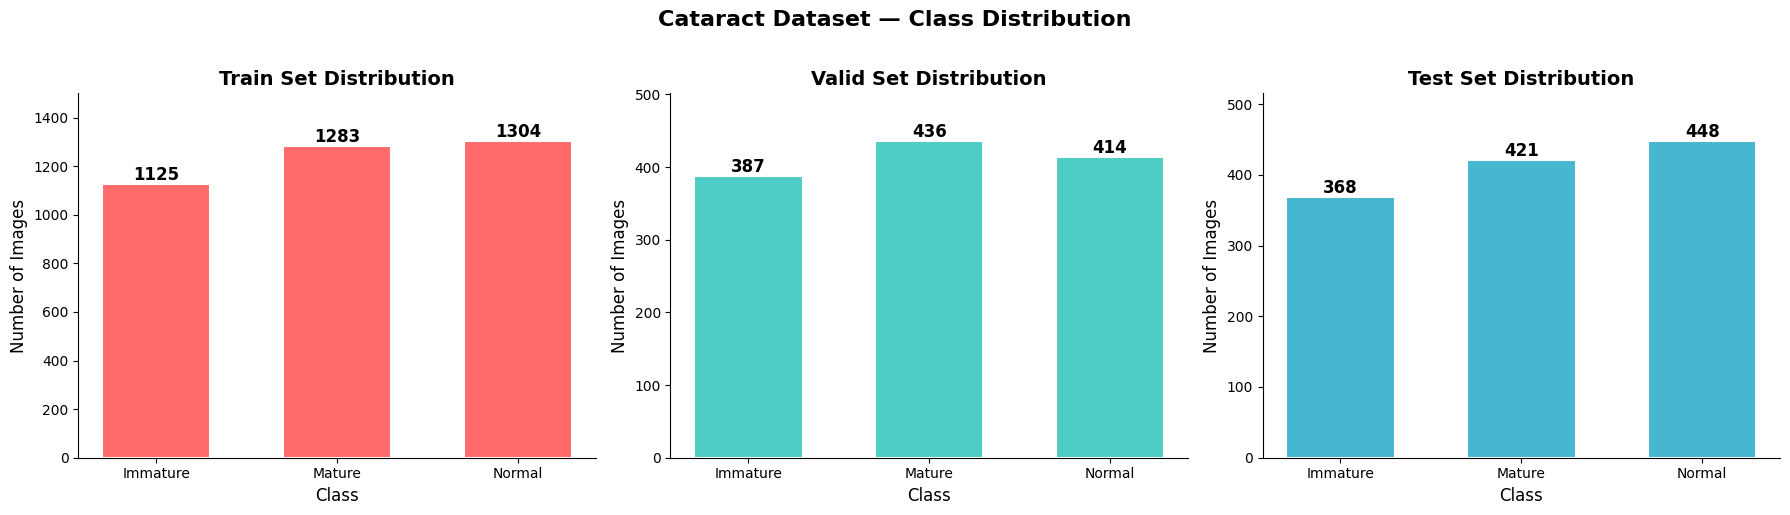


  DATASET SUMMARY
  Class           Train      Valid      Test       Total     
-------------------------------------------------------
  Immature        1125       387        368        1880      
  Mature          1283       436        421        2140      
  Normal          1304       414        448        2166      


In [8]:
# ============================================================
# Dataset Visualization: Class Distribution
# ============================================================

def count_images_per_class(dataset_path, split='train'):
    """Count images in each class for a given split."""
    split_path = os.path.join(dataset_path, split)
    counts = {}
    for cls in CATARACT_CLASSES:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            counts[cls] = 0
    return counts


# --- Plot class distribution for all splits ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = ['train', 'valid', 'test']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, split, color in zip(axes, splits, colors):
    counts = count_images_per_class(DATASET_PATH, split)
    bars = ax.bar(counts.keys(), counts.values(), color=color,
                  edgecolor='white', linewidth=1.5, width=0.6)
    ax.set_title(f'{split.capitalize()} Set Distribution',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(counts.values()) * 1.15 if counts else 1)

plt.suptitle('Cataract Dataset — Class Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# --- Print summary table ---
print("\n" + "=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  {'Class':<15} {'Train':<10} {'Valid':<10} {'Test':<10} {'Total':<10}")
print("-" * 55)
for cls in CATARACT_CLASSES:
    t = count_images_per_class(DATASET_PATH, 'train')[cls]
    v = count_images_per_class(DATASET_PATH, 'valid')[cls]
    te = count_images_per_class(DATASET_PATH, 'test')[cls]
    print(f"  {cls:<15} {t:<10} {v:<10} {te:<10} {t + v + te:<10}")
print("=" * 55)

## Cell 8: Sample Images from Each Class

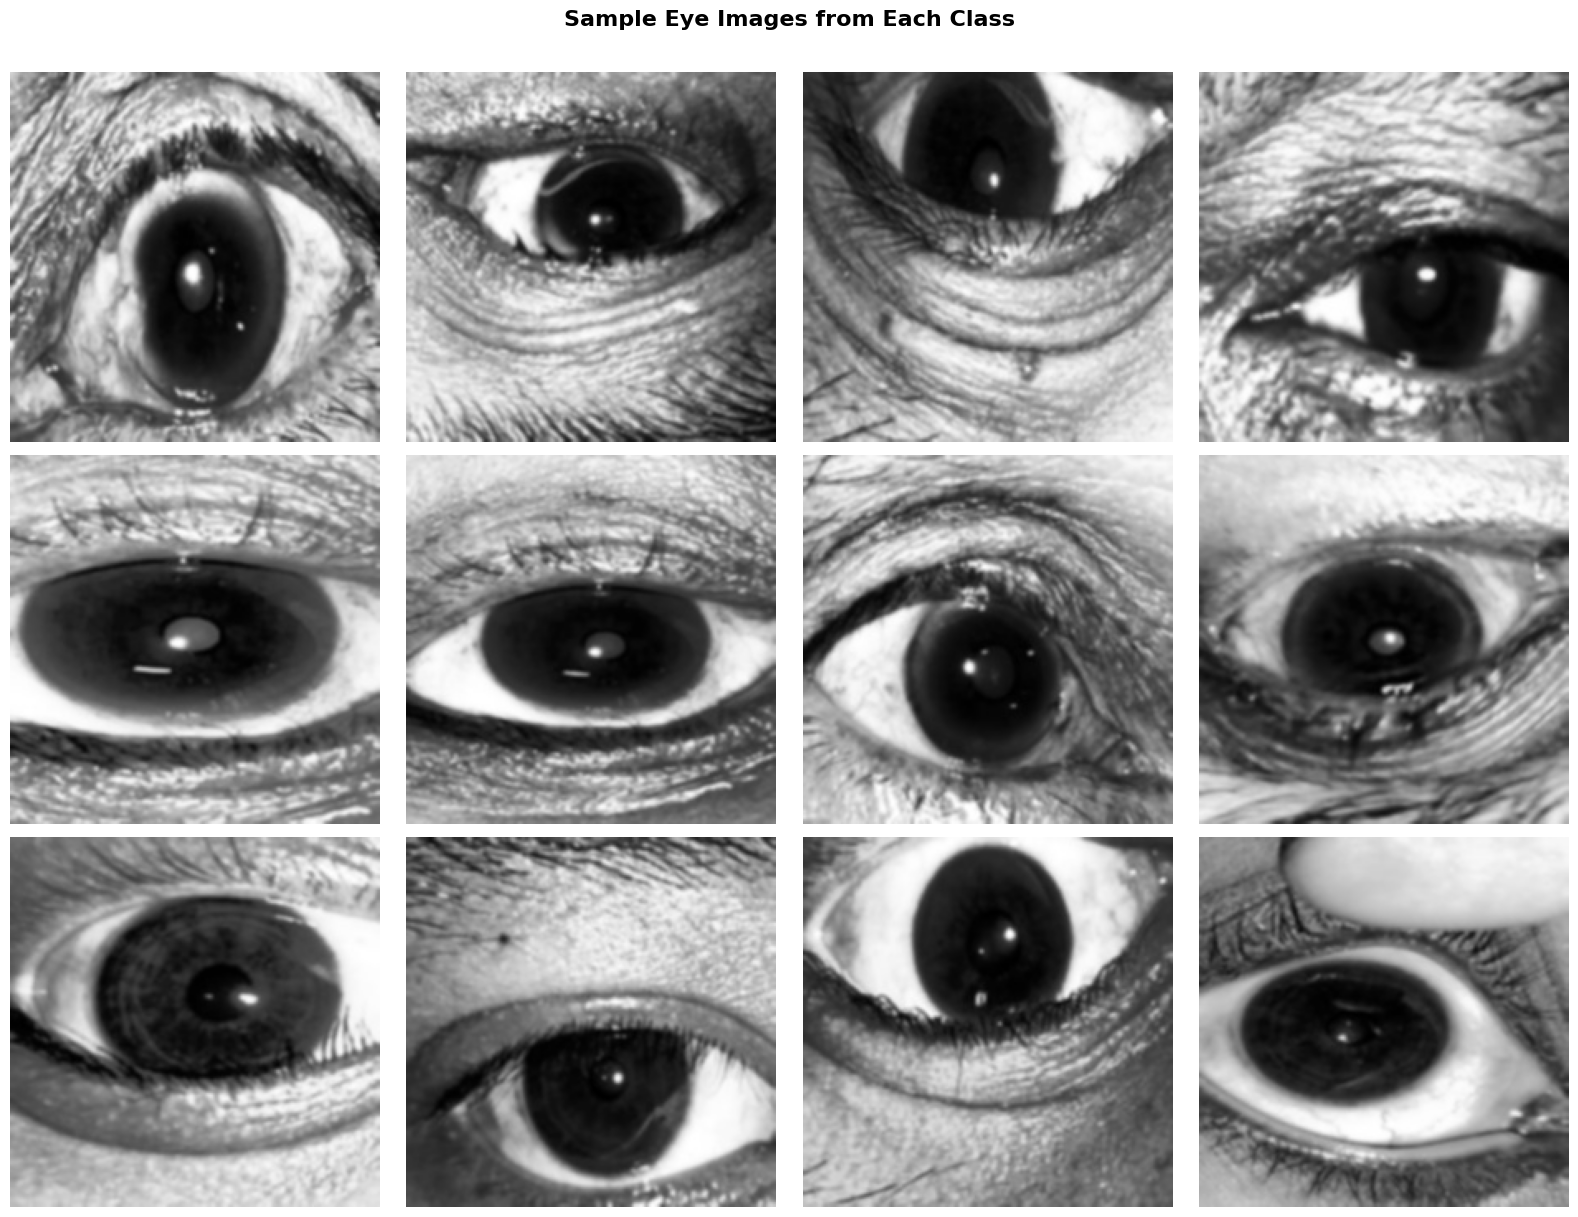

In [9]:
# ============================================================
# Dataset Visualization: Sample Images from Each Class
# ============================================================

def show_sample_images(dataset_path, split='train', samples_per_class=4):
    """Display sample images from each class in a grid."""
    fig, axes = plt.subplots(len(CATARACT_CLASSES), samples_per_class,
                             figsize=(4 * samples_per_class, 4 * len(CATARACT_CLASSES)))

    for row, cls in enumerate(CATARACT_CLASSES):
        cls_path = os.path.join(dataset_path, split, cls)
        if not os.path.exists(cls_path):
            continue

        all_images = [f for f in os.listdir(cls_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        images = random.sample(all_images,
                               min(samples_per_class, len(all_images)))

        for col, img_name in enumerate(images):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, fontsize=14,
                                          fontweight='bold', rotation=0,
                                          labelpad=80)

    plt.suptitle('Sample Eye Images from Each Class',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

show_sample_images(DATASET_PATH, 'train', samples_per_class=4)

## Cell 9: Visualize Preprocessing Pipeline Effects

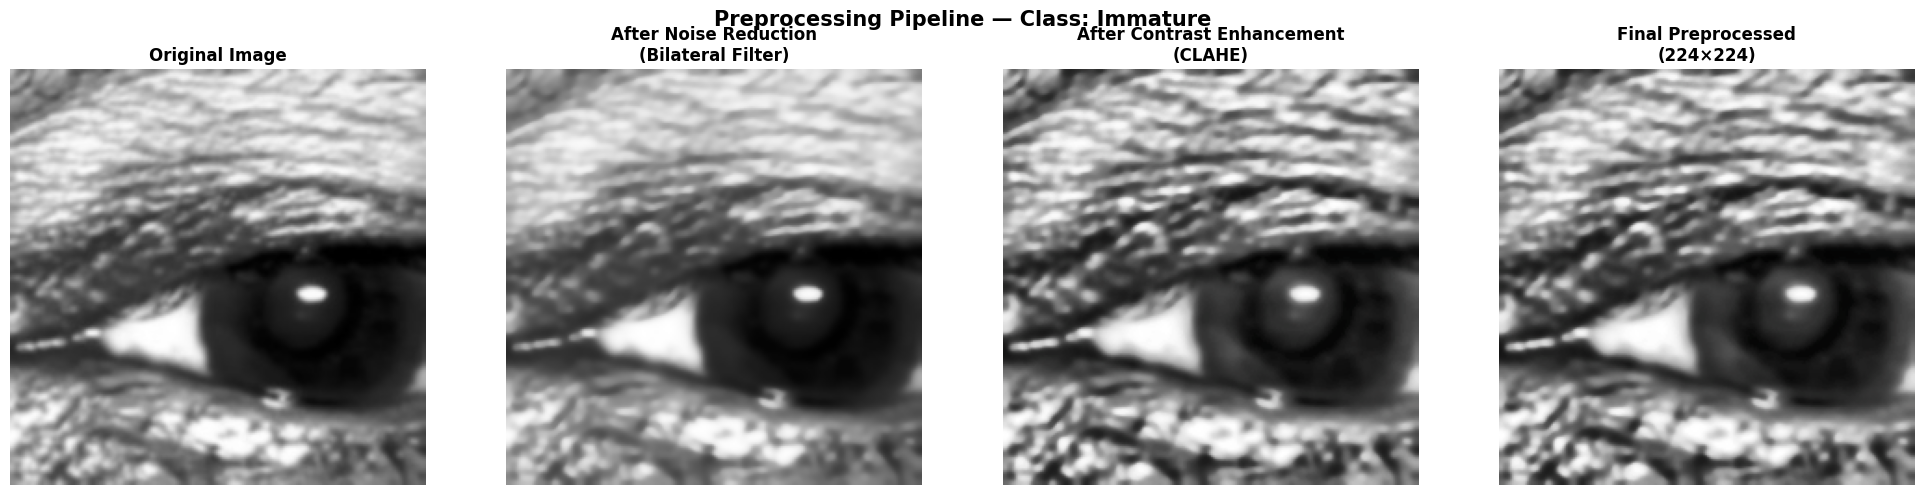


Showing augmented training samples...


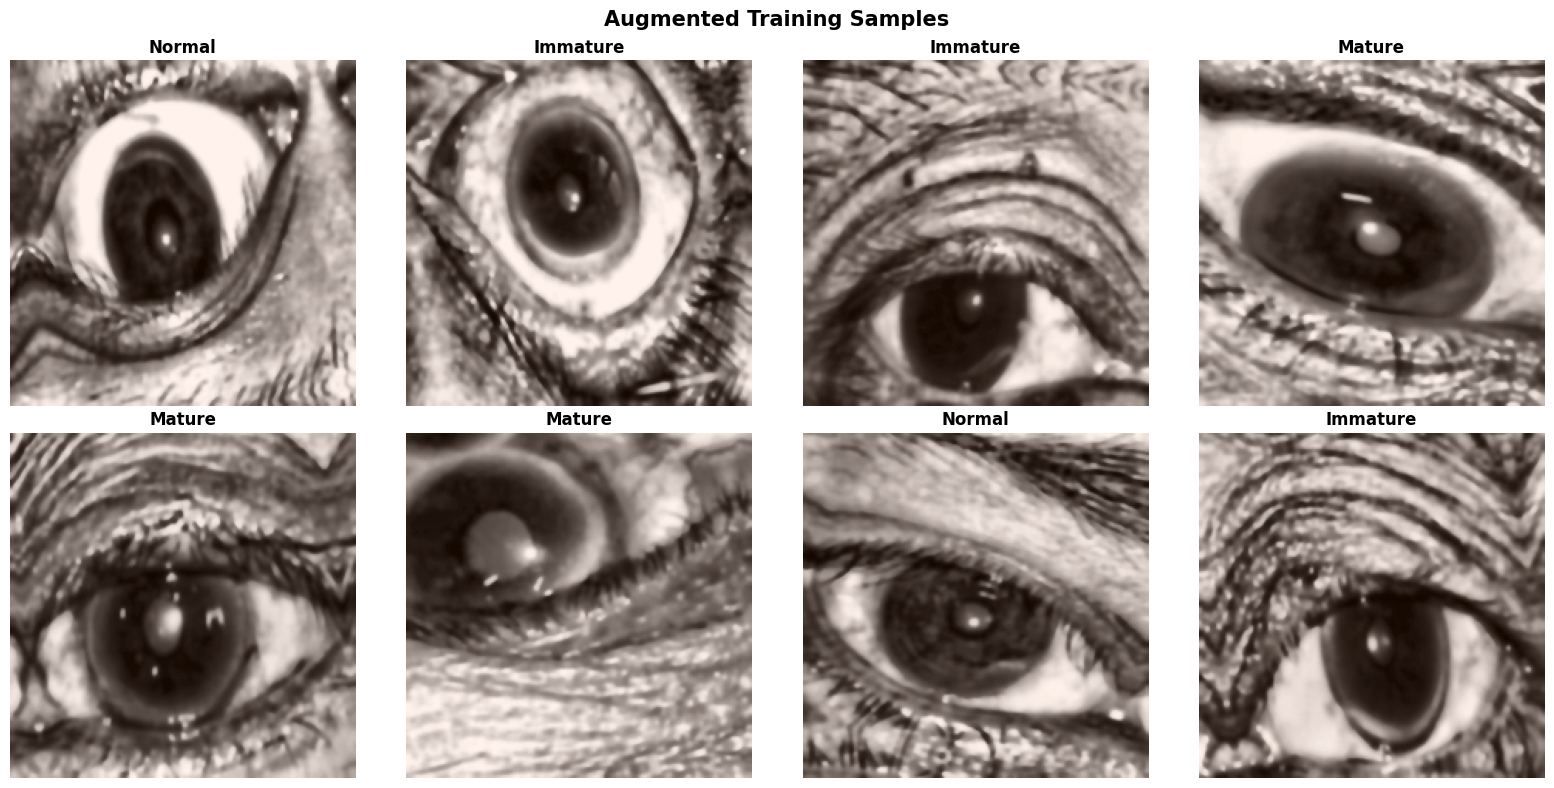

In [10]:
# ============================================================
# Visualize Preprocessing Pipeline Effects
# ============================================================

def show_preprocessing_effects(dataset_path):
    """Show original vs preprocessed images step by step."""
    # Pick a random image
    cls = random.choice(CATARACT_CLASSES)
    cls_path = os.path.join(dataset_path, 'train', cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Load original
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Apply each preprocessing step
    denoised = reduce_noise(original)          # Step 1: Noise reduction
    enhanced = apply_clahe(denoised)           # Step 2: CLAHE
    resized = cv2.resize(enhanced, (IMG_SIZE, IMG_SIZE))  # Step 3: Resize

    # Plot all steps
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ['Original Image', 'After Noise Reduction\n(Bilateral Filter)',
              'After Contrast Enhancement\n(CLAHE)', 'Final Preprocessed\n(224×224)']
    images = [original, denoised, enhanced, resized]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'Preprocessing Pipeline — Class: {cls}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR,
                'preprocessing_effects.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

show_preprocessing_effects(DATASET_PATH)

# --- Show augmented samples ---
print("\nShowing augmented training samples...")
augmented_batch = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < len(augmented_batch[0]):
        img = augmented_batch[0][i]
        # Denormalize for display
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        label_idx = np.argmax(augmented_batch[1][i])
        ax.set_title(CATARACT_CLASSES[label_idx],
                     fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Augmented Training Samples',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Stage 1: Eye Image Detector (MobileNetV2)

Build and train a MobileNetV2-based binary classifier to detect whether an image is an eye image. Includes dataset preparation, training with fine-tuning, and evaluation.

---


## Cell 10: Prepare Eye Detector Dataset

**Strategy:**
- **Eye images**: All images from the cataract dataset (they are all eye images)
- **Non-Eye images**: Downloaded from TensorFlow Flowers dataset (clearly not eye images)
- Split: 70% train / 15% valid / 15% test

This creates a balanced binary dataset for eye vs non-eye classification.

In [11]:
!pip install importlib-resources -q

In [12]:
# ============================================================
# STAGE 1: EYE IMAGE DETECTOR
# Prepare Eye vs Non-Eye Dataset
# ============================================================

import tensorflow_datasets as tfds

# Create eye detector dataset directory structure
EYE_DATASET_PATH = '/content/eye_detector_dataset'
for split in ['train', 'valid', 'test']:
    for cls in ['eye', 'non_eye']:
        os.makedirs(os.path.join(EYE_DATASET_PATH, split, cls), exist_ok=True)

print("Created eye detector dataset directory structure.")

# --------------------------------------------------
# Collect all eye image paths from cataract dataset
# --------------------------------------------------
eye_image_paths = []
for split in ['train', 'valid', 'test']:
    for cls in CATARACT_CLASSES:
        cls_path = os.path.join(DATASET_PATH, split, cls)
        if os.path.exists(cls_path):
            for img_name in os.listdir(cls_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    eye_image_paths.append(os.path.join(cls_path, img_name))

print(f"Total eye images from cataract dataset: {len(eye_image_paths)}")

# --------------------------------------------------
# Download non-eye images (TensorFlow Flowers dataset)
# --------------------------------------------------
print("Downloading non-eye images from TensorFlow Flowers dataset...")
ds, ds_info = tfds.load('tf_flowers', split='train',
                        as_supervised=True, with_info=True)
print(f"Flowers dataset: {ds_info.splits['train'].num_examples} images available")

non_eye_temp = os.path.join(EYE_DATASET_PATH, 'non_eye_temp')
os.makedirs(non_eye_temp, exist_ok=True)

non_eye_count = 0
target_count = len(eye_image_paths)  # Match number of eye images
for img, label in tfds.as_numpy(ds):
    if non_eye_count >= target_count:
        break
    img_path = os.path.join(non_eye_temp, f'non_eye_{non_eye_count}.jpg')
    cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    non_eye_count += 1

print(f"Downloaded {non_eye_count} non-eye images")

# --------------------------------------------------
# Split into train / valid / test (70 / 15 / 15)
# --------------------------------------------------
random.shuffle(eye_image_paths)
non_eye_paths = [os.path.join(non_eye_temp, f) for f in os.listdir(non_eye_temp)]
random.shuffle(non_eye_paths)

def split_paths(paths, ratios=(0.7, 0.15, 0.15)):
    """Split paths into train/valid/test by ratios."""
    n = len(paths)
    train_end = int(ratios[0] * n)
    valid_end = int((ratios[0] + ratios[1]) * n)
    return {
        'train': paths[:train_end],
        'valid': paths[train_end:valid_end],
        'test': paths[valid_end:]
    }

eye_splits = split_paths(eye_image_paths)
non_eye_splits = split_paths(non_eye_paths)

# Copy files to organized directories
for split in ['train', 'valid', 'test']:
    for src in eye_splits[split]:
        dst = os.path.join(EYE_DATASET_PATH, split, 'eye', os.path.basename(src))
        shutil.copy(src, dst)
    for src in non_eye_splits[split]:
        dst = os.path.join(EYE_DATASET_PATH, split, 'non_eye', os.path.basename(src))
        shutil.copy(src, dst)

# Print counts
print("\nEye Detector Dataset:")
print("-" * 40)
for split in ['train', 'valid', 'test']:
    e = len(os.listdir(os.path.join(EYE_DATASET_PATH, split, 'eye')))
    ne = len(os.listdir(os.path.join(EYE_DATASET_PATH, split, 'non_eye')))
    print(f"  {split:<6} | eye={e:<6} | non_eye={ne:<6} | total={e + ne}")
print("-" * 40)
print("✓ Eye detector dataset prepared.")

Created eye detector dataset directory structure.
Total eye images from cataract dataset: 6186


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.NO6B9M_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Flowers dataset: 3670 images available
Downloaded 3670 non-eye images

Eye Detector Dataset:
----------------------------------------
  train  | eye=2944   | non_eye=2569   | total=5513
  valid  | eye=851    | non_eye=550    | total=1401
  test   | eye=848    | non_eye=551    | total=1399
----------------------------------------
✓ Eye detector dataset prepared.


### Important: Restart Runtime

If you encounter an `AttributeError` related to `tensorflow_datasets` (e.g., `module 'tensorflow_datasets' has no attribute 'load'`), it means the Python kernel has not fully reloaded the newly installed library.

Please restart the Colab runtime (go to **Runtime > Restart runtime** in the menu) and then re-run all cells from the beginning to ensure all library changes are applied correctly.

## Cell 11: Create Eye Detector Data Generators

In [13]:
# ============================================================
# Stage 1: Create Data Generators for Eye Detector
# ============================================================

# Augmentation for eye detector training
eye_train_datagen = ImageDataGenerator(
    preprocessing_function=eye_preprocessing_function,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='reflect'
)

eye_val_datagen = ImageDataGenerator(
    preprocessing_function=eye_preprocessing_function
)

# Create generators
eye_train_gen = eye_train_datagen.flow_from_directory(
    os.path.join(EYE_DATASET_PATH, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_eye', 'eye'],
    shuffle=True,
    seed=SEED
)

eye_valid_gen = eye_val_datagen.flow_from_directory(
    os.path.join(EYE_DATASET_PATH, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_eye', 'eye'],
    shuffle=False,
    seed=SEED
)

eye_test_gen = eye_val_datagen.flow_from_directory(
    os.path.join(EYE_DATASET_PATH, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_eye', 'eye'],
    shuffle=False,
    seed=SEED
)

print(f"\n✓ Eye detector generators created:")
print(f"  Train: {eye_train_gen.samples} samples")
print(f"  Valid: {eye_valid_gen.samples} samples")
print(f"  Test:  {eye_test_gen.samples} samples")
print(f"  Class indices: {eye_train_gen.class_indices}")


Found 5513 images belonging to 2 classes.
Found 1401 images belonging to 2 classes.
Found 1399 images belonging to 2 classes.

✓ Eye detector generators created:
  Train: 5513 samples
  Valid: 1401 samples
  Test:  1399 samples
  Class indices: {'non_eye': 0, 'eye': 1}


## Cell 12: Build Eye Detector Model (MobileNetV2)

**Architecture:**
- MobileNetV2 backbone (ImageNet pretrained, frozen initially)
- Global Average Pooling
- Dense(128) + BatchNorm + Dropout(0.5)
- Dense(64) + Dropout(0.3)
- Dense(1, sigmoid) — binary output (eye vs non-eye)

In [14]:
# ============================================================
# Stage 1: Build Eye Detector Model (MobileNetV2)
# ============================================================

def build_eye_detector():
    """Build MobileNetV2-based binary eye detector.

    Architecture:
      - MobileNetV2 backbone (ImageNet pretrained)
      - Global Average Pooling
      - Dense layers with Dropout & BatchNorm
      - Sigmoid output (binary: eye / non-eye)

    Returns:
      model: Compiled Keras model
      base_model: The MobileNetV2 base (for fine-tuning later)
    """
    # Load pretrained MobileNetV2 (without classification head)
    base_model = MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze for feature extraction

    # Build classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')  # Binary: eye=1, non-eye=0
    ], name='eye_detector')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    return model, base_model


# Build the model
eye_model, eye_base = build_eye_detector()
eye_model.summary()

# Print parameter counts
total_params = eye_model.count_params()
trainable_params = sum(np.prod(w.shape) for w in eye_model.trainable_weights)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "eye_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,785 (9.27 MB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


Total parameters:     2,430,785
Trainable parameters: 172,545
Frozen parameters:    2,258,240


## Cell 13: Train Eye Detector

**Two-phase training:**
1. **Feature Extraction** — backbone frozen, only train classification head
2. **Fine-Tuning** — unfreeze top 40 layers of MobileNetV2, train with lower LR

**Callbacks:** EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [15]:
# ============================================================
# Stage 1: Train Eye Detector
# ============================================================

# Define callbacks
eye_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'eye_detector_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# --------------------------------------------------
# Phase 1: Feature Extraction (frozen backbone)
# --------------------------------------------------
print("=" * 60)
print("  TRAINING STAGE 1: EYE DETECTOR")
print("  Phase 1: Feature Extraction (frozen backbone)")
print("=" * 60)

eye_history = eye_model.fit(
    eye_train_gen,
    epochs=EPOCHS_STAGE1,
    validation_data=eye_valid_gen,
    callbacks=eye_callbacks,
    verbose=1
)

# --------------------------------------------------
# Phase 2: Fine-Tuning (unfreeze top layers)
# --------------------------------------------------
print("\n" + "=" * 60)
print("  FINE-TUNING EYE DETECTOR")
print("  Phase 2: Unfreezing top 40 layers of MobileNetV2")
print("=" * 60)

eye_base.trainable = True

# Freeze early layers, unfreeze last 40
for layer in eye_base.layers[:-40]:
    layer.trainable = False

trainable_count = sum(1 for l in eye_base.layers if l.trainable)
print(f"Trainable layers in base model: {trainable_count}")

# Recompile with lower learning rate
eye_model.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

eye_history_fine = eye_model.fit(
    eye_train_gen,
    epochs=EPOCHS_STAGE1,
    validation_data=eye_valid_gen,
    callbacks=eye_callbacks,
    verbose=1
)

# Save final model
eye_model_path = os.path.join(SAVE_DIR, 'eye_detector.keras')
eye_model.save(eye_model_path)
print(f"\n✓ Eye detector saved to: {eye_model_path}")


  TRAINING STAGE 1: EYE DETECTOR
  Phase 1: Feature Extraction (frozen backbone)
Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.8432 - auc: 0.9106 - loss: 0.3504 - precision: 0.8820 - recall: 0.7980
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/cataract_models/eye_detector_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cataract_models/eye_detector_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 161s 802ms/step - accuracy: 0.9380 - auc: 0.9858 - loss: 0.1687 - precision: 0.9610 - recall: 0.9212 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0125 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0271 - precision: 0.9986 - recall: 0.9997
Epoch 2: val_accuracy did not improve from 1.00000
173/173 ━━━━━━━━━━━━━━━━━━━━ 106s 612ms/step - accuracy: 0.9984 - auc: 1.0000 - loss: 0.0238 - pr

## Cell 14: Plot Eye Detector Training History

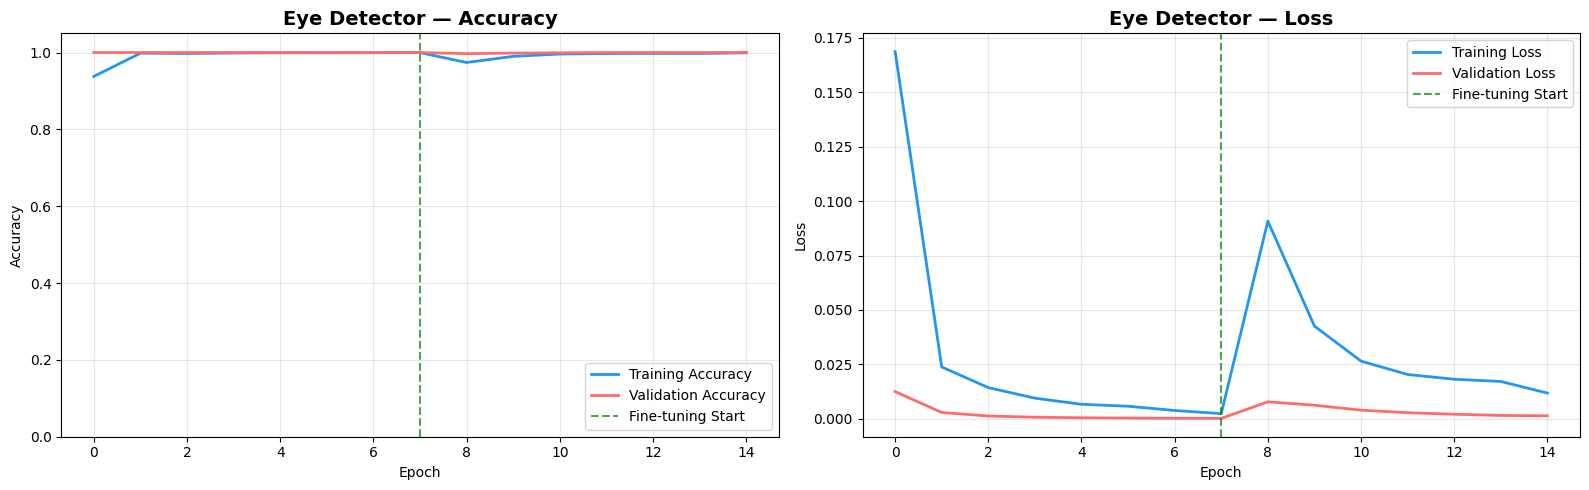

In [16]:
# ============================================================
# Stage 1: Plot Training History
# ============================================================

def plot_training_history(history, history_fine, title):
    """Plot training & validation accuracy and loss curves.

    Combines feature extraction and fine-tuning phases,
    with a vertical line marking the fine-tuning start.
    """
    # Combine histories
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']

    # Mark fine-tuning start point
    fine_tune_epoch = len(history.history['accuracy'])
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- Accuracy Plot ---
    axes[0].plot(epochs_range, acc, label='Training Accuracy',
                 color='#2196F3', linewidth=2)
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy',
                 color='#FF6B6B', linewidth=2)
    axes[0].axvline(x=fine_tune_epoch - 1, color='green',
                    linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0].set_title(f'{title} — Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    # --- Loss Plot ---
    axes[1].plot(epochs_range, loss, label='Training Loss',
                 color='#2196F3', linewidth=2)
    axes[1].plot(epochs_range, val_loss, label='Validation Loss',
                 color='#FF6B6B', linewidth=2)
    axes[1].axvline(x=fine_tune_epoch - 1, color='green',
                    linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1].set_title(f'{title} — Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR,
                f'{title.lower().replace(" ", "_")}_history.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_training_history(eye_history, eye_history_fine, 'Eye Detector')

## Cell 15: Evaluate Eye Detector on Test Set

44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 529ms/step
  EYE DETECTOR — TEST RESULTS
  Accuracy:  0.9993 (99.93%)
  Precision: 0.9988
  Recall:    1.0000
  F1-Score:  0.9994

Classification Report:
              precision    recall  f1-score   support

     Non-Eye       1.00      1.00      1.00       551
         Eye       1.00      1.00      1.00       848

    accuracy                           1.00      1399
   macro avg       1.00      1.00      1.00      1399
weighted avg       1.00      1.00      1.00      1399



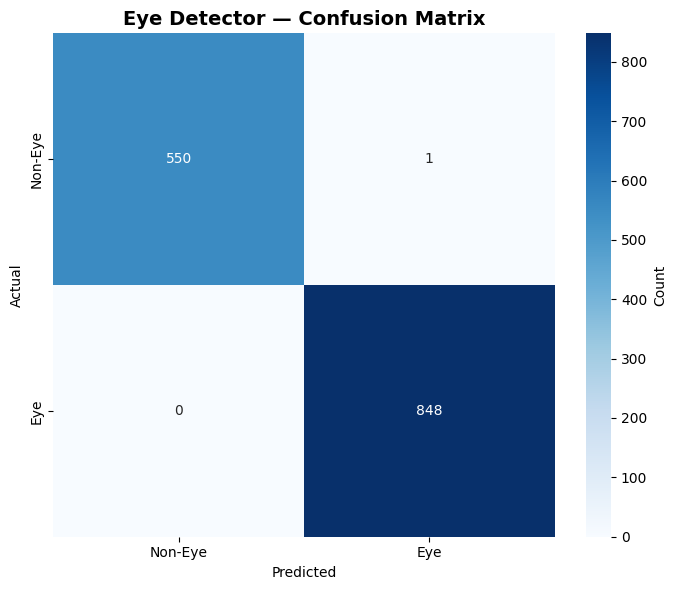

In [17]:
# ============================================================
# Stage 1: Evaluate Eye Detector
# ============================================================

# Get predictions on test set
eye_test_gen.reset()
eye_predictions = eye_model.predict(eye_test_gen, verbose=1)
eye_pred_classes = (eye_predictions > EYE_CONFIDENCE_THRESHOLD).astype(int).flatten()
eye_true_classes = eye_test_gen.classes

# Compute metrics
eye_accuracy = accuracy_score(eye_true_classes, eye_pred_classes)
eye_precision = precision_score(eye_true_classes, eye_pred_classes)
eye_recall = recall_score(eye_true_classes, eye_pred_classes)
eye_f1 = f1_score(eye_true_classes, eye_pred_classes)

print("=" * 50)
print("  EYE DETECTOR — TEST RESULTS")
print("=" * 50)
print(f"  Accuracy:  {eye_accuracy:.4f} ({eye_accuracy * 100:.2f}%)")
print(f"  Precision: {eye_precision:.4f}")
print(f"  Recall:    {eye_recall:.4f}")
print(f"  F1-Score:  {eye_f1:.4f}")
print("=" * 50)

# Classification report
print("\nClassification Report:")
print(classification_report(eye_true_classes, eye_pred_classes,
                           target_names=['Non-Eye', 'Eye']))

# Confusion matrix
cm_eye = confusion_matrix(eye_true_classes, eye_pred_classes)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_eye, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Eye', 'Eye'],
            yticklabels=['Non-Eye', 'Eye'],
            cbar_kws={'label': 'Count'})
plt.title('Eye Detector — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eye_detector_confusion_matrix.png'),
            dpi=150)
plt.show()


# Stage 2: Cataract Classifier (ResNet50)

Build and train a ResNet50-based cataract classifier with feature extraction and fine-tuning. Uses categorical crossentropy, Adam optimizer, class weights, and all three callbacks.

---


## Cell 16: Build Cataract Classifier (ResNet50)

**Architecture:**
- ResNet50 backbone (ImageNet pretrained, frozen initially)
- Global Average Pooling
- Dense(256) + BatchNorm + Dropout(0.5)
- Dense(128) + BatchNorm + Dropout(0.3)
- Dense(3, softmax) — 3 classes: Immature, Mature, Normal

**Loss:** Categorical Crossentropy
**Optimizer:** Adam

In [18]:
# ============================================================
# STAGE 2: CATARACT CLASSIFIER
# Build ResNet50-based Model
# ============================================================

def build_cataract_classifier():
    """Build ResNet50-based cataract classifier.

    Architecture:
      - ResNet50 backbone (ImageNet pretrained, frozen initially)
      - Global Average Pooling
      - Dense(256) + BatchNorm + Dropout(0.5)
      - Dense(128) + BatchNorm + Dropout(0.3)
      - Dense(3, softmax) — 3 classes

    Returns:
      model: Compiled Keras model
      base_model: The ResNet50 base (for fine-tuning later)
    """
    # Load pretrained ResNet50 (without classification head)
    base_model = ResNet50(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze for feature extraction

    # Build classification head using Functional API
    inputs = keras.Input(shape=IMG_SHAPE)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='cataract_classifier')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc', multi_label=True),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    return model, base_model


# Build the model
cataract_model, cataract_base = build_cataract_classifier()
cataract_model.summary()

# Print parameter counts
total_params = cataract_model.count_params()
trainable_params = sum(np.prod(w.shape) for w in cataract_model.trainable_weights)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cataract_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,075 (92.11 MB)

 Trainable params: 558,595 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)


Total parameters:     24,147,075
Trainable parameters: 558,595
Frozen parameters:    23,588,480


## Cell 17: Train Cataract Classifier — Phase 1 (Feature Extraction)

**Callbacks:**
- **EarlyStopping** — stop if val_accuracy does not improve for 10 epochs
- **ReduceLROnPlateau** — reduce LR by 0.3× if val_loss plateaus for 4 epochs
- **ModelCheckpoint** — save best model based on val_accuracy

**Class weights** are computed to handle class imbalance.

In [19]:
# ============================================================
# Stage 2: Train Cataract Classifier — Phase 1 (Feature Extraction)
# ============================================================

# Define callbacks
cataract_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'cataract_classifier_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# --------------------------------------------------
# Compute class weights for imbalanced data
# --------------------------------------------------
train_labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
print(f"Class weights: {class_weights}")

# --------------------------------------------------
# Phase 1: Feature Extraction (frozen backbone)
# --------------------------------------------------
print("=" * 60)
print("  TRAINING STAGE 2: CATARACT CLASSIFIER")
print("  Phase 1: Feature Extraction (frozen backbone)")
print("=" * 60)

cataract_history = cataract_model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=valid_generator,
    callbacks=cataract_callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n✓ Phase 1 (Feature Extraction) complete.")


Class weights: {0: np.float64(1.0998518518518519), 1: np.float64(0.9644063393089114), 2: np.float64(0.9488752556237219)}
  TRAINING STAGE 2: CATARACT CLASSIFIER
  Phase 1: Feature Extraction (frozen backbone)
Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.4595 - auc: 0.6394 - loss: 1.4462 - precision: 0.4755 - recall: 0.4231
Epoch 1: val_accuracy improved from None to 0.75101, saving model to /content/drive/MyDrive/cataract_models/cataract_classifier_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cataract_models/cataract_classifier_best.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 120s 903ms/step - accuracy: 0.5423 - auc: 0.7247 - loss: 1.1946 - precision: 0.5613 - recall: 0.5059 - val_accuracy: 0.7510 - val_auc: 0.9259 - val_loss: 0.5676 - val_precision: 0.7771 - val_recall: 0.7017 - learning_rate: 1.0000e-04
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.6617 - auc: 0.8382 - loss: 0.8437 - precision: 0.6756 - recall: 0.6269
Epoch 

## Cell 18: Fine-Tune Cataract Classifier — Phase 2

Unfreeze the top 50 layers of ResNet50 and continue training with a lower learning rate (1e-5) for careful fine-tuning.

In [20]:
# ============================================================
# Stage 2: Fine-Tune Cataract Classifier — Phase 2
# ============================================================

print("=" * 60)
print("  FINE-TUNING CATARACT CLASSIFIER")
print("  Phase 2: Unfreezing top 50 layers of ResNet50")
print("=" * 60)

# Unfreeze the base model
cataract_base.trainable = True

# Freeze early layers, only fine-tune the last 50 layers
for layer in cataract_base.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in cataract_base.layers if l.trainable)
print(f"Trainable layers in base model: {trainable_count}")

# Recompile with lower learning rate for fine-tuning
cataract_model.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc', multi_label=True),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Continue training
cataract_history_fine = cataract_model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=valid_generator,
    callbacks=cataract_callbacks,
    class_weight=class_weights,
    verbose=1
)

# Save final model
cataract_model_path = os.path.join(SAVE_DIR, 'cataract_classifier.keras')
cataract_model.save(cataract_model_path)
print(f"\n✓ Cataract classifier saved to: {cataract_model_path}")


  FINE-TUNING CATARACT CLASSIFIER
  Phase 2: Unfreezing top 50 layers of ResNet50
Trainable layers in base model: 50
Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.8108 - auc: 0.9381 - loss: 0.5337 - precision: 0.8169 - recall: 0.8051
Epoch 1: val_accuracy did not improve from 0.99596
116/116 ━━━━━━━━━━━━━━━━━━━━ 124s 826ms/step - accuracy: 0.8400 - auc: 0.9517 - loss: 0.4509 - precision: 0.8462 - recall: 0.8346 - val_accuracy: 0.9790 - val_auc: 0.9993 - val_loss: 0.0574 - val_precision: 0.9790 - val_recall: 0.9790 - learning_rate: 1.0000e-05
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9044 - auc: 0.9776 - loss: 0.2797 - precision: 0.9088 - recall: 0.8996
Epoch 2: val_accuracy did not improve from 0.99596
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 764ms/step - accuracy: 0.9049 - auc: 0.9789 - loss: 0.2687 - precision: 0.9090 - recall: 0.9011 - val_accuracy: 0.9838 - val_auc: 0.9996 - val_loss: 0.0434 - val_precision: 0.9838 - val_recall: 0.9830 - lear

## Cell 19: Plot Cataract Classifier Training History

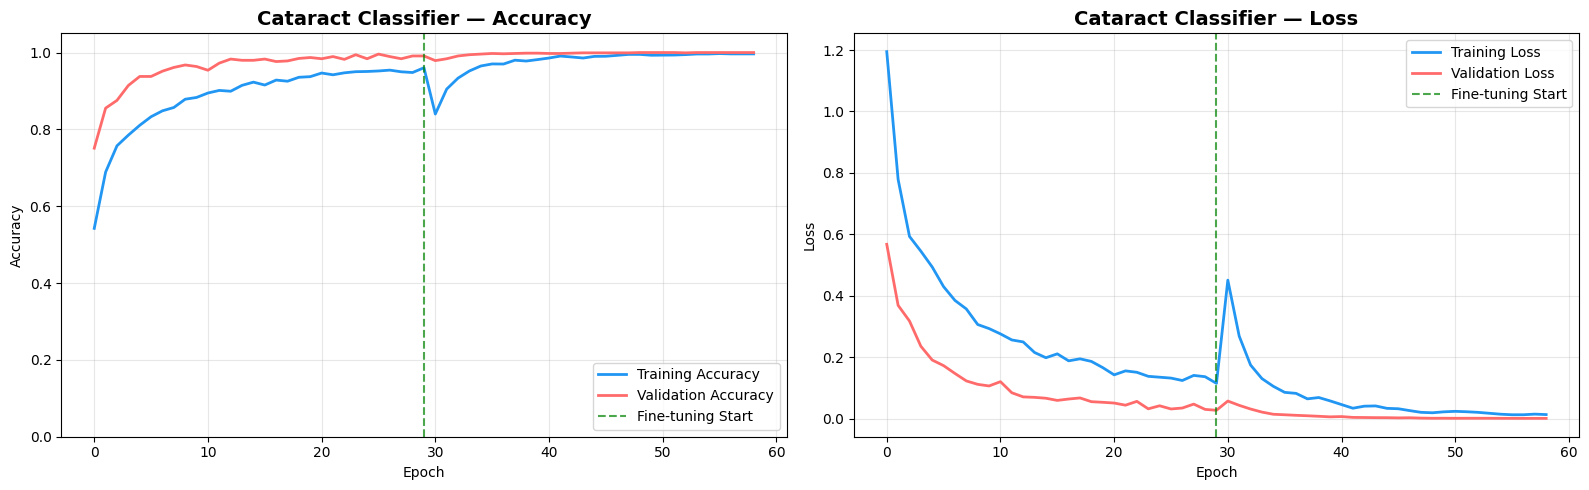

In [21]:
# ============================================================
# Stage 2: Plot Training History
# ============================================================

plot_training_history(cataract_history, cataract_history_fine,
                      'Cataract Classifier')

# Model Evaluation & Medical Metrics

Comprehensive evaluation: accuracy, precision, recall, F1-score, confusion matrix, sensitivity, specificity, ROC curves, and AUC for medical research validation.

---


## Cell 20: Predictions & Classification Report

In [22]:
# ============================================================
# EVALUATION: Cataract Classifier on Test Set
# ============================================================

# Reset generator and get predictions
test_generator.reset()
y_pred_probs = cataract_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_generator.classes

# Overall accuracy
test_accuracy = accuracy_score(y_true_classes, y_pred_classes)

print("=" * 60)
print("  CATARACT CLASSIFIER — TEST RESULTS")
print("=" * 60)
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print("=" * 60)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=CATARACT_CLASSES,
    digits=4
))

# Per-class metrics summary
print("\nPer-Class Metrics:")
print("-" * 65)
for i, cls in enumerate(CATARACT_CLASSES):
    p = precision_score(y_true_classes, y_pred_classes, labels=[i], average='macro')
    r = recall_score(y_true_classes, y_pred_classes, labels=[i], average='macro')
    f1 = f1_score(y_true_classes, y_pred_classes, labels=[i], average='macro')
    print(f"  {cls:<15} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f}")
print("-" * 65)


39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 351ms/step
  CATARACT CLASSIFIER — TEST RESULTS
  Test Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

    Immature     1.0000    1.0000    1.0000       368
      Mature     1.0000    1.0000    1.0000       421
      Normal     1.0000    1.0000    1.0000       448

    accuracy                         1.0000      1237
   macro avg     1.0000    1.0000    1.0000      1237
weighted avg     1.0000    1.0000    1.0000      1237


Per-Class Metrics:
-----------------------------------------------------------------
  Immature        | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
  Mature          | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
  Normal          | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
-----------------------------------------------------------------


## Cell 21: Confusion Matrix

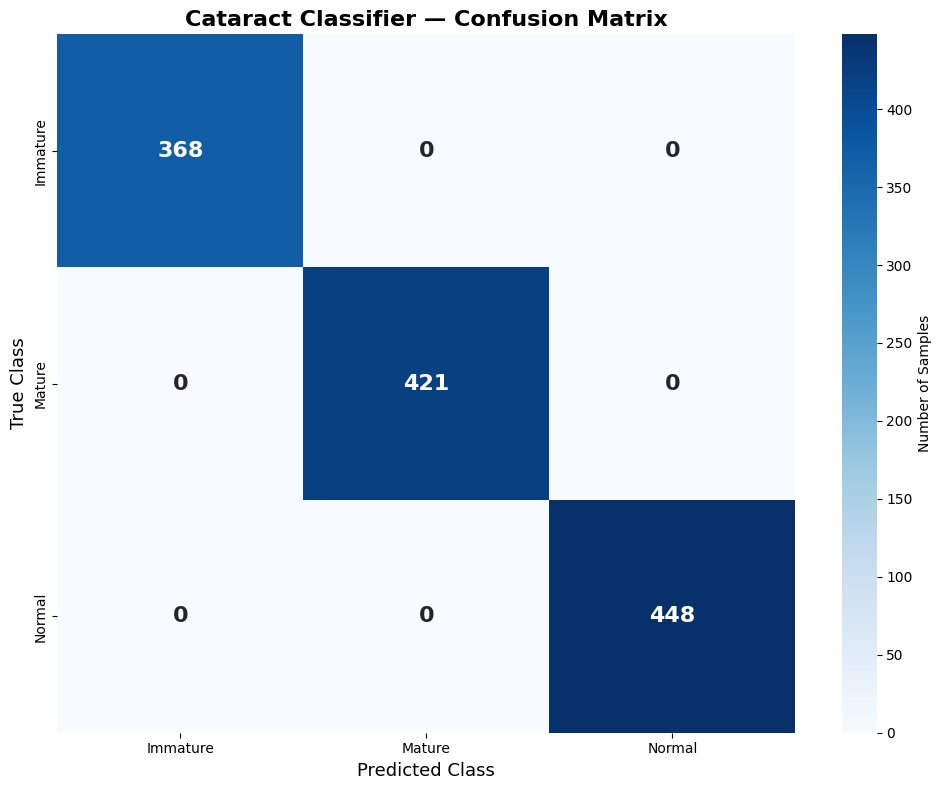

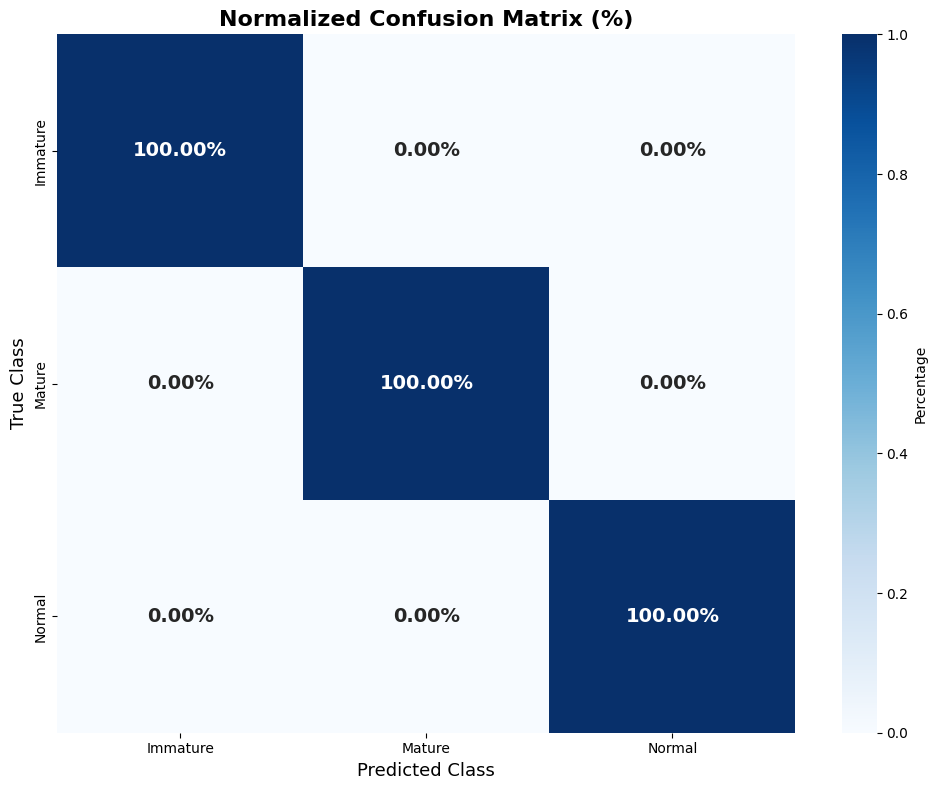

In [23]:
# ============================================================
# Evaluation: Confusion Matrix
# ============================================================

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# --- Raw confusion matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATARACT_CLASSES,
            yticklabels=CATARACT_CLASSES,
            cbar_kws={'label': 'Number of Samples'},
            annot_kws={'size': 16, 'fontweight': 'bold'})
plt.title('Cataract Classifier — Confusion Matrix',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('True Class', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cataract_confusion_matrix.png'), dpi=150)
plt.show()

# --- Normalized confusion matrix (percentages) ---
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CATARACT_CLASSES,
            yticklabels=CATARACT_CLASSES,
            cbar_kws={'label': 'Percentage'},
            annot_kws={'size': 14, 'fontweight': 'bold'})
plt.title('Normalized Confusion Matrix (%)',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('True Class', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cataract_confusion_matrix_normalized.png'),
            dpi=150)
plt.show()

## Cell 22: Sensitivity & Specificity (Medical Metrics)

**Sensitivity (Recall / TPR)** = TP / (TP + FN) — ability to correctly identify positive cases
**Specificity (TNR)** = TN / (TN + FP) — ability to correctly identify negative cases

These are critical metrics for medical diagnosis systems.

  SENSITIVITY & SPECIFICITY (Medical Evaluation)
   Class  TP  FP  TN  FN  Sensitivity  Specificity
Immature 368   0 869   0       1.0000       1.0000
  Mature 421   0 816   0       1.0000       1.0000
  Normal 448   0 789   0       1.0000       1.0000


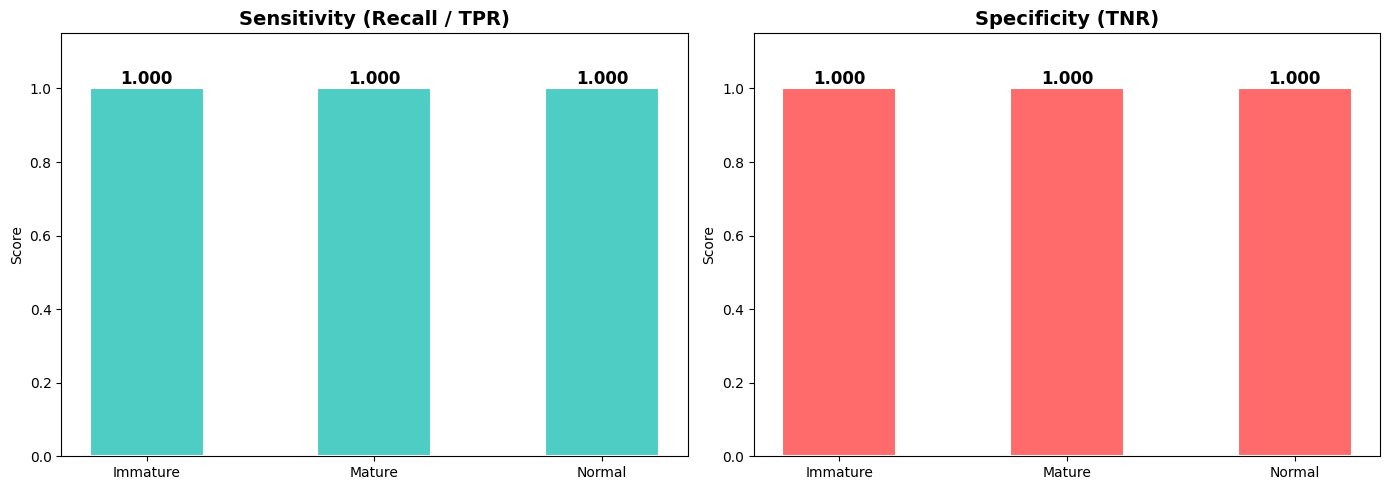

In [24]:
# ============================================================
# Evaluation: Sensitivity & Specificity (Medical Metrics)
# ============================================================

def compute_sensitivity_specificity(cm, class_names):
    """Compute sensitivity and specificity for each class.

    Sensitivity = TP / (TP + FN)  — True Positive Rate
    Specificity = TN / (TN + FP)  — True Negative Rate

    Args:
        cm: Confusion matrix (numpy array)
        class_names: List of class names
    Returns:
        DataFrame with TP, FP, TN, FN, Sensitivity, Specificity
    """
    results = []
    n = cm.sum()

    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = n - TP - FN - FP

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

        results.append({
            'Class': cls,
            'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
            'Sensitivity': sensitivity,
            'Specificity': specificity
        })

    return pd.DataFrame(results)


# Compute metrics
metrics_df = compute_sensitivity_specificity(cm, CATARACT_CLASSES)

print("=" * 70)
print("  SENSITIVITY & SPECIFICITY (Medical Evaluation)")
print("=" * 70)
print(metrics_df.to_string(index=False, float_format='%.4f'))
print("=" * 70)

# --- Visualize Sensitivity & Specificity ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(CATARACT_CLASSES))
width = 0.5

# Sensitivity
bars1 = axes[0].bar(x, metrics_df['Sensitivity'], width,
                     color='#4ECDC4', edgecolor='white', linewidth=1.5)
axes[0].set_title('Sensitivity (Recall / TPR)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATARACT_CLASSES)
axes[0].set_ylim(0, 1.15)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=12)

# Specificity
bars2 = axes[1].bar(x, metrics_df['Specificity'], width,
                     color='#FF6B6B', edgecolor='white', linewidth=1.5)
axes[1].set_title('Specificity (TNR)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CATARACT_CLASSES)
axes[1].set_ylim(0, 1.15)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sensitivity_specificity.png'), dpi=150)
plt.show()

## Cell 23: ROC Curve & AUC (Multi-class)

Plots ROC curves for each class (one-vs-rest), plus micro-average and macro-average curves. AUC (Area Under Curve) is computed for each.

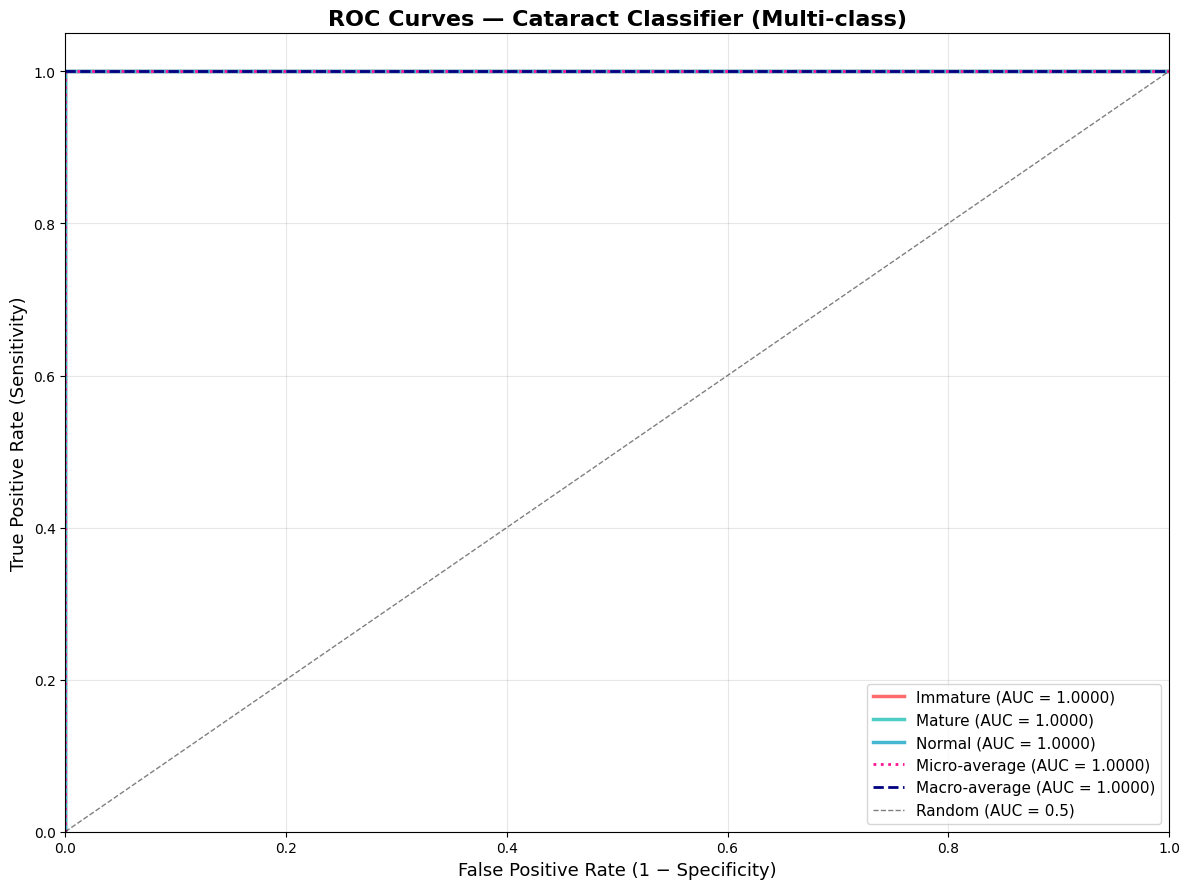


  AUC SCORES
  Immature       : 1.0000
  Mature         : 1.0000
  Normal         : 1.0000
  Micro-avg      : 1.0000
  Macro-avg      : 1.0000


In [25]:
# ============================================================
# Evaluation: ROC Curve & AUC (Multi-class)
# ============================================================

# Binarize true labels for multi-class ROC (one-vs-rest)
y_true_binarized = label_binarize(y_true_classes, classes=list(range(NUM_CLASSES)))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)

# --- Plot ROC curves ---
plt.figure(figsize=(12, 9))
colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, cls in enumerate(CATARACT_CLASSES):
    plt.plot(fpr[i], tpr[i], color=colors_roc[i], linewidth=2.5,
             label=f'{cls} (AUC = {roc_auc[i]:.4f})')

# Micro and macro averages
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':',
         linewidth=2, label=f'Micro-average (AUC = {roc_auc_micro:.4f})')
plt.plot(fpr_macro, tpr_macro, color='navy', linestyle='--',
         linewidth=2, label=f'Macro-average (AUC = {roc_auc_macro:.4f})')

# Diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5,
         label='Random (AUC = 0.5)')

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate (1 − Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.title('ROC Curves — Cataract Classifier (Multi-class)',
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve.png'), dpi=150)
plt.show()

# Print AUC scores
print("\n" + "=" * 50)
print("  AUC SCORES")
print("=" * 50)
for i, cls in enumerate(CATARACT_CLASSES):
    print(f"  {cls:<15}: {roc_auc[i]:.4f}")
print(f"  {'Micro-avg':<15}: {roc_auc_micro:.4f}")
print(f"  {'Macro-avg':<15}: {roc_auc_macro:.4f}")
print("=" * 50)


## Cell 24: Complete Metrics Summary Table

In [26]:
# ============================================================
# Evaluation: Complete Metrics Summary Table
# ============================================================

# Compute per-class metrics
precision_per_class = precision_score(y_true_classes, y_pred_classes, average=None)
recall_per_class = recall_score(y_true_classes, y_pred_classes, average=None)
f1_per_class = f1_score(y_true_classes, y_pred_classes, average=None)

# Build summary DataFrame
summary_data = {
    'Class': CATARACT_CLASSES,
    'Precision': precision_per_class,
    'Recall (Sensitivity)': recall_per_class,
    'F1-Score': f1_per_class,
    'Specificity': metrics_df['Specificity'].values,
    'AUC': [roc_auc[i] for i in range(NUM_CLASSES)]
}
summary_df = pd.DataFrame(summary_data)

# Add overall (weighted) metrics
overall = pd.DataFrame({
    'Class': ['Overall (Weighted)'],
    'Precision': [precision_score(y_true_classes, y_pred_classes, average='weighted')],
    'Recall (Sensitivity)': [recall_score(y_true_classes, y_pred_classes, average='weighted')],
    'F1-Score': [f1_score(y_true_classes, y_pred_classes, average='weighted')],
    'Specificity': [metrics_df['Specificity'].mean()],
    'AUC': [roc_auc_macro]
})

final_summary = pd.concat([summary_df, overall], ignore_index=True)

print("\n" + "=" * 80)
print("  COMPLETE EVALUATION SUMMARY — CATARACT CLASSIFIER")
print("=" * 80)
print(final_summary.to_string(index=False, float_format='%.4f'))
print("=" * 80)

# Save to CSV
metrics_csv_path = os.path.join(SAVE_DIR, 'evaluation_metrics.csv')
final_summary.to_csv(metrics_csv_path, index=False)
print(f"\n✓ Metrics saved to: {metrics_csv_path}")



  COMPLETE EVALUATION SUMMARY — CATARACT CLASSIFIER
             Class  Precision  Recall (Sensitivity)  F1-Score  Specificity    AUC
          Immature     1.0000                1.0000    1.0000       1.0000 1.0000
            Mature     1.0000                1.0000    1.0000       1.0000 1.0000
            Normal     1.0000                1.0000    1.0000       1.0000 1.0000
Overall (Weighted)     1.0000                1.0000    1.0000       1.0000 1.0000

✓ Metrics saved to: /content/drive/MyDrive/cataract_models/evaluation_metrics.csv


# Final Prediction System

The complete two-stage prediction pipeline: eye detection first, then cataract classification. Returns JSON with status, prediction, and confidence.

---


## Cell 25: Final Prediction System

**Two-stage pipeline:**
1. **Stage 1 — Eye Detection**: Load image → preprocess → MobileNetV2 → if eye_prob < threshold → reject
2. **Stage 2 — Cataract Classification**: If eye detected → ResNet50 → softmax → return prediction with confidence

**Output format:**
```json
{
  "status": "Success",
  "prediction": "Mature Cataract",
  "confidence": "95.00%"
}
```

Or if rejected:
```json
{
  "status": "Rejected",
  "message": "Please upload an eye image"
}
```

In [27]:
# ============================================================
# FINAL PREDICTION SYSTEM
# Two-Stage Pipeline: Eye Detection → Cataract Classification
# ============================================================

def predict_image(image_path,
                  eye_model_path=os.path.join(SAVE_DIR, 'eye_detector.keras'),
                  cataract_model_path=os.path.join(SAVE_DIR, 'cataract_classifier.keras'),
                  eye_threshold=EYE_CONFIDENCE_THRESHOLD,
                  verbose=True):
    """
    Complete two-stage prediction pipeline for cataract detection.

    Stage 1: Eye Detection — verify the image is an eye image
    Stage 2: Cataract Classification — grade the cataract severity

    Args:
        image_path (str): Path to the input image
        eye_model_path (str): Path to saved eye detector model
        cataract_model_path (str): Path to saved cataract classifier model
        eye_threshold (float): Confidence threshold for eye detection
        verbose (bool): If True, print detailed information

    Returns:
        dict: Prediction result with status, prediction, and confidence
    """

    # --- Load models ---
    eye_detector = tf.keras.models.load_model(eye_model_path)
    cataract_classifier = tf.keras.models.load_model(cataract_model_path)

    # --- Load and validate image ---
    if not os.path.exists(image_path):
        return {"status": "Error", "message": f"Image not found: {image_path}"}

    image = cv2.imread(image_path)
    if image is None:
        return {"status": "Error", "message": "Could not read image file."}
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Apply preprocessing (CLAHE + noise reduction + resize)
    processed = preprocess_eye_image(image_rgb)

    if verbose:
        print(f"Input image: {image_path}")
        print(f"Image shape: {image.shape}")

    # ============================================
    # STAGE 1: EYE DETECTION
    # ============================================+
    # Prepare input for MobileNetV2
    eye_input = mobilenet_preprocess(processed.astype(np.float32))
    eye_input = np.expand_dims(eye_input, axis=0)  # Add batch dimension

    # Predict eye probability
    eye_probability = float(eye_detector.predict(eye_input, verbose=0)[0][0])
    non_eye_probability = 1.0 - eye_probability

    if verbose:
        print(f"\n{'─' * 50}")
        print(f"  STAGE 1: EYE DETECTION")
        print(f"{'─' * 50}")
        print(f"  Eye probability:     {eye_probability:.4f} ({eye_probability * 100:.2f}%)")
        print(f"  Non-eye probability: {non_eye_probability:.4f} ({non_eye_probability * 100:.2f}%)")
        print(f"  Threshold:           {eye_threshold}")

    # Check if image is an eye
    if eye_probability < eye_threshold:
        result = {
            "status": "Rejected",
            "message": "Please upload an eye image",
            "stage": "Eye Detection",
            "eye_probability": f"{eye_probability * 100:.2f}%",
            "non_eye_probability": f"{non_eye_probability * 100:.2f}%"
        }
        if verbose:
            print("\n  ⚠ REJECTED: Image does not appear to be an eye image.")
        return result

    if verbose:
        print(f"  ✓ PASSED: Eye image detected.")

    # ============================================+
    # STAGE 2: CATARACT CLASSIFICATION
    # ============================================+
    # Prepare input for ResNet50
    cataract_input = resnet_preprocess(processed.astype(np.float32))
    cataract_input = np.expand_dims(cataract_input, axis=0)

    # Predict cataract class
    predictions = cataract_classifier.predict(cataract_input, verbose=0)[0]
    predicted_class_idx = int(np.argmax(predictions))
    predicted_class = CATARACT_CLASSES[predicted_class_idx]
    confidence = float(predictions[predicted_class_idx])

    if verbose:
        print(f"\n{'─' * 50}")
        print(f"  STAGE 2: CATARACT CLASSIFICATION")
        print(f"{'─' * 50}")
        for i, cls in enumerate(CATARACT_CLASSES):
            bar = '█' * int(predictions[i] * 20)
            print(f"  {cls:<15}: {predictions[i] * 100:6.2f}%  {bar}")
        print(f"\n  ► Predicted:  {predicted_class}")
        print(f"  ► Confidence: {confidence * 100:.2f}%")

    # Build result
    result = {
        "status": "Success",
        "prediction": predicted_class,
        "confidence": f"{confidence * 100:.2f}%",
        "stage": "Cataract Classification",
        "all_predictions": {
            CATARACT_CLASSES[i]: f"{predictions[i] * 100:.2f}%"
            for i in range(NUM_CLASSES)
        },
        "eye_probability": f"{eye_probability * 100:.2f}%"
    }

    return result


# ============================================================+
# Test the prediction system with a sample image
# ============================================================+
print("=" * 60)
print("  TESTING PREDICTION SYSTEM")
print("=" * 60)

# Test with a sample from the test set
for cls in CATARACT_CLASSES:
    test_dir = os.path.join(DATASET_PATH, 'test', cls)
    if os.path.exists(test_dir) and len(os.listdir(test_dir)) > 0:
        sample_img = os.path.join(test_dir, sorted(os.listdir(test_dir))[0])
        print(f"\nTesting with: {cls} sample\n")
        result = predict_image(sample_img, verbose=True)
        print(f"\n{'=' * 60}")
        print(f"  JSON OUTPUT:")
        print(f"{'=' * 60}")
        print(json.dumps(result, indent=2))
        break

print(f"\n✓ Prediction system ready.")
print(f"  Usage: predict_image('/path/to/image.jpg')")


  TESTING PREDICTION SYSTEM

Testing with: Immature sample

Input image: /content/drive/MyDrive/Processed_Cataract_Data/test/Immature/Immature (1).jpg
Image shape: (224, 224, 3)

──────────────────────────────────────────────────
  STAGE 1: EYE DETECTION
──────────────────────────────────────────────────
  Eye probability:     1.0000 (100.00%)
  Non-eye probability: 0.0000 (0.00%)
  Threshold:           0.5
  ✓ PASSED: Eye image detected.

──────────────────────────────────────────────────
  STAGE 2: CATARACT CLASSIFICATION
──────────────────────────────────────────────────
  Immature       :  99.81%  ███████████████████
  Mature         :   0.18%  
  Normal         :   0.00%  

  ► Predicted:  Immature
  ► Confidence: 99.81%

  JSON OUTPUT:
{
  "status": "Success",
  "prediction": "Immature",
  "confidence": "99.81%",
  "stage": "Cataract Classification",
  "all_predictions": {
    "Immature": "99.81%",
    "Mature": "0.18%",
    "Normal": "0.00%"
  },
  "eye_probability": "100.00%"
}

## Cell 26: Visualize Prediction Results

Displays the image with its prediction overlay — green for Normal, red for cataract, orange for rejected.

Testing prediction system with sample images from each class...

--- Immature ---


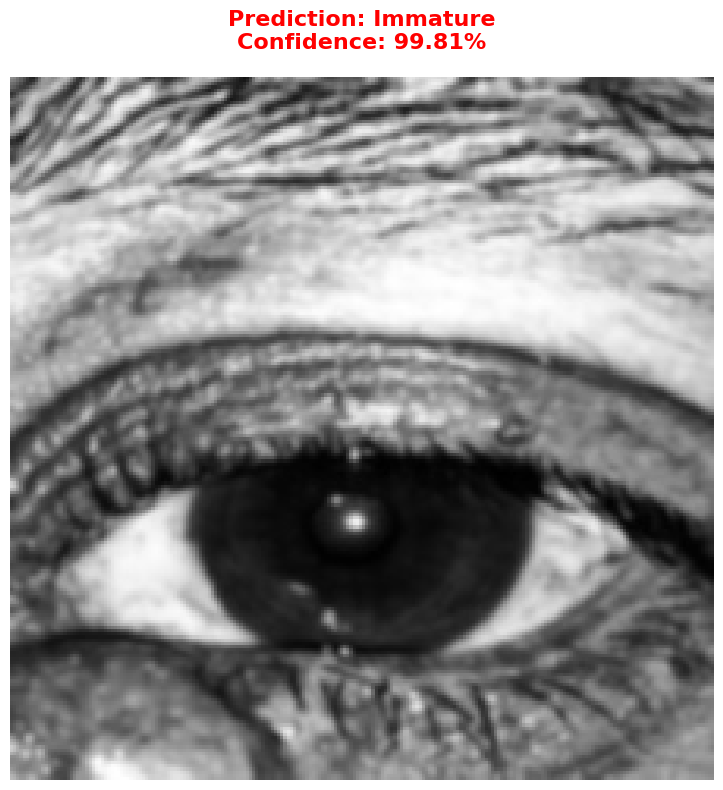


--- Mature ---


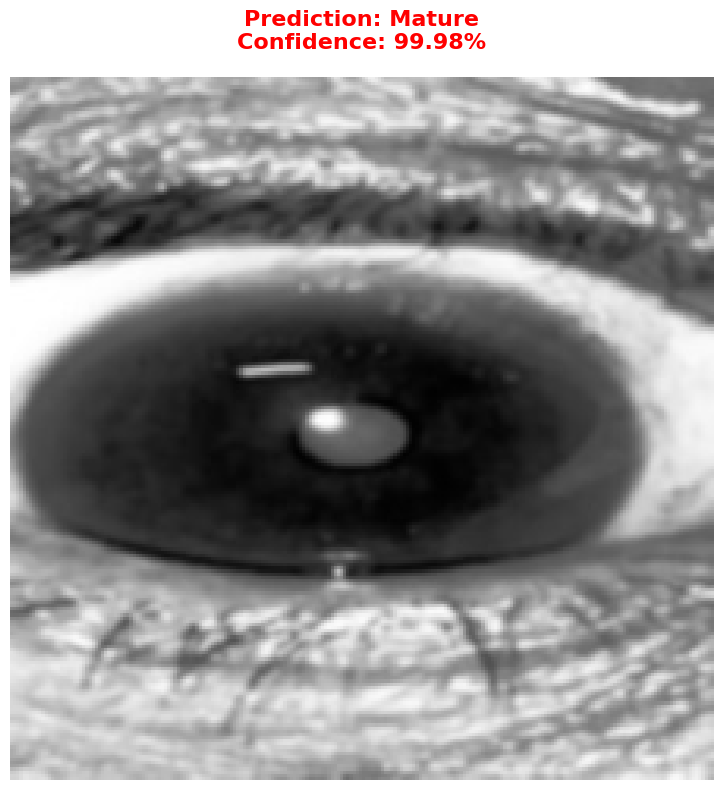


--- Normal ---


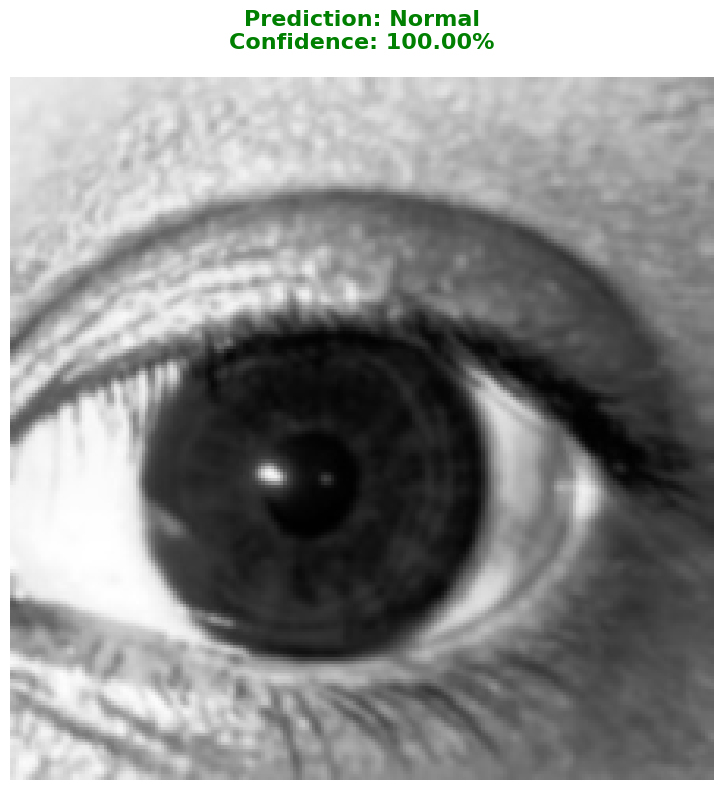

In [28]:
# ============================================================
# Visualize Prediction Results
# ============================================================

def visualize_prediction(image_path):
    """Visualize the prediction pipeline with image and results."""
    result = predict_image(image_path, verbose=False)

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image)
    ax.axis('off')

    # Set title based on result
    if result['status'] == 'Success':
        title = f"Prediction: {result['prediction']}\nConfidence: {result['confidence']}"
        color = 'green' if result['prediction'] == 'Normal' else 'red'
    else:
        title = f"REJECTED\n{result['message']}"
        color = 'orange'

    ax.set_title(title, fontsize=16, fontweight='bold',
                 color=color, pad=20)
    plt.tight_layout()
    plt.show()
    return result


# Test with one sample from each class
print("Testing prediction system with sample images from each class...\n")
for cls in CATARACT_CLASSES:
    test_dir = os.path.join(DATASET_PATH, 'test', cls)
    if os.path.exists(test_dir) and len(os.listdir(test_dir)) > 0:
        sample = os.path.join(test_dir, sorted(os.listdir(test_dir))[0])
        print(f"--- {cls} ---")
        visualize_prediction(sample)
        print()


## Cell 27: Batch Testing & Final Summary

Runs predictions on multiple test images and reports batch accuracy.

In [29]:
# ============================================================
# Batch Testing & Final Summary
# ============================================================

def batch_predict(test_dir, max_per_class=5):
    """Run predictions on a batch of test images."""
    results = []
    for cls in CATARACT_CLASSES:
        cls_dir = os.path.join(test_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        images = sorted(os.listdir(cls_dir))[:max_per_class]
        for img_name in images:
            img_path = os.path.join(cls_dir, img_name)
            result = predict_image(img_path, verbose=False)
            result['true_class'] = cls
            result['image_name'] = img_name
            results.append(result)
    return results


# Run batch predictions
print("=" * 70)
print("  BATCH PREDICTION SUMMARY")
print("=" * 70)

batch_results = batch_predict(os.path.join(DATASET_PATH, 'test'), max_per_class=5)

correct = 0
total = 0
for r in batch_results:
    if r['status'] == 'Success':
        total += 1
        is_correct = r['prediction'] == r['true_class']
        if is_correct:
            correct += 1
        status = "✓" if is_correct else "✗"
        print(f"  {status} {r['image_name']:<30} True: {r['true_class']:<12} "
              f"Pred: {r['prediction']:<12} ({r['confidence']})")
    else:
        print(f"  ⚠ {r['image_name']:<30} REJECTED: {r['message']}")

print("-" * 70)
if total > 0:
    print(f"  Batch Accuracy: {correct}/{total} = {correct / total * 100:.1f}%")
print("=" * 70)

# Final summary
print("\n" + "=" * 60)
print("  PIPELINE COMPLETE")
print("=" * 60)
print(f"""
  Models saved to Google Drive:
    1. Eye Detector:        {SAVE_DIR}/eye_detector.keras
    2. Cataract Classifier:  {SAVE_DIR}/cataract_classifier.keras

  To use the prediction system:
    result = predict_image('/path/to/image.jpg')
    print(result)
""")
print("=" * 60)


  BATCH PREDICTION SUMMARY
  ✓ Immature (1).jpg               True: Immature     Pred: Immature     (99.81%)
  ✓ Immature (10).jpg              True: Immature     Pred: Immature     (99.92%)
  ✓ Immature (100).jpg             True: Immature     Pred: Immature     (99.99%)
  ✓ Immature (101).jpg             True: Immature     Pred: Immature     (99.93%)
  ✓ Immature (102).jpg             True: Immature     Pred: Immature     (100.00%)
  ✓ Mature (1).jpg                 True: Mature       Pred: Mature       (99.98%)
  ✓ Mature (10).jpg                True: Mature       Pred: Mature       (99.97%)
  ✓ Mature (100).jpg               True: Mature       Pred: Mature       (100.00%)
  ✓ Mature (101).jpg               True: Mature       Pred: Mature       (99.99%)
  ✓ Mature (102).jpg               True: Mature       Pred: Mature       (100.00%)
  ✓ Normal (1).jpg                 True: Normal       Pred: Normal       (100.00%)
  ✓ Normal (10).jpg                True: Normal       Pred: Normal 

Input image: /content/WhatsApp Image 2026-08-27 at 16.31.04.jpeg
Image shape: (1600, 1116, 3)

──────────────────────────────────────────────────
  STAGE 1: EYE DETECTION
──────────────────────────────────────────────────
  Eye probability:     0.8409 (84.09%)
  Non-eye probability: 0.1591 (15.91%)
  Threshold:           0.5
  ✓ PASSED: Eye image detected.

──────────────────────────────────────────────────
  STAGE 2: CATARACT CLASSIFICATION
──────────────────────────────────────────────────
  Immature       :   0.01%  
  Mature         :   0.10%  
  Normal         :  99.90%  ███████████████████

  ► Predicted:  Normal
  ► Confidence: 99.90%
{'status': 'Success', 'prediction': 'Normal', 'confidence': '99.90%', 'stage': 'Cataract Classification', 'all_predictions': {'Immature': '0.01%', 'Mature': '0.10%', 'Normal': '99.90%'}, 'eye_probability': '84.09%'}


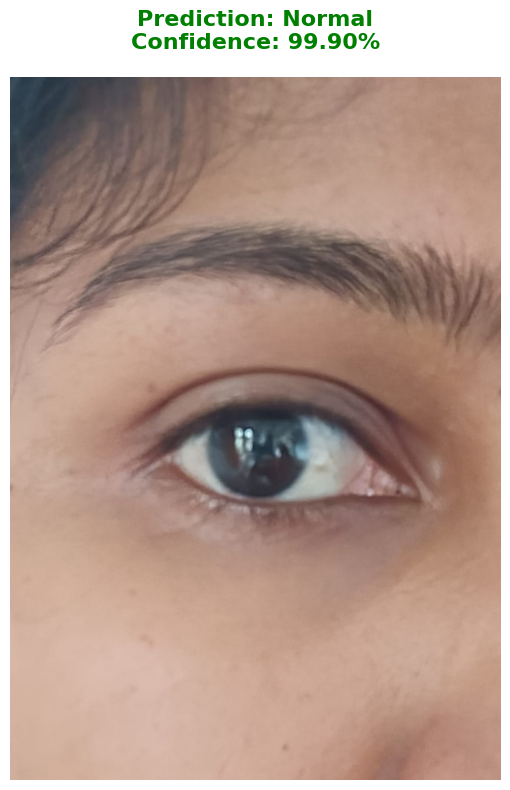

{'status': 'Success',
 'prediction': 'Normal',
 'confidence': '99.90%',
 'stage': 'Cataract Classification',
 'all_predictions': {'Immature': '0.01%',
  'Mature': '0.10%',
  'Normal': '99.90%'},
 'eye_probability': '84.09%'}

In [35]:

image_path = '/content/WhatsApp Image 2026-08-27 at 16.31.04.jpeg'


result = predict_image(image_path)
print(result)


visualize_prediction(image_path)